## 질문

레벨6과 레벨7 사이(6.5)는 어떤 연봉이 합리적일까?

STEP#1 - 라이브러리 임포트

In [3]:
# pandas, numpy, sklearn, matplotlib

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

STEP#2 - 데이터 불러오기<br>
X: 입력 ( feature ) - level( 직급 단계 ) - 2차원<br>
y: 정답( target or label ) = Salary( 연봉 )<br>

In [5]:
df = pd.read_csv('../../data/Position_Salaries.csv')
# 첫번째: 컬럼 -> 전체 행임, 두번쟤: 열 - 1번 인덱스 부터 마지막 전까지
X = df.iloc[:, 1:-1].values
X

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [6]:
# 첫번째 행은 컬럼명 이기 때문에 필요가 없음
y = df.iloc[:, -1].values
# y축은 행이므로 skip
# 1번째 부터 마지막 까지
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

STEP#3 - 학습데이터 / 테스트 데이터 분리

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) # 알고리즘 훈련

STEP#4 - 모델 준비( 심화학습 - 비교실습 )

In [8]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=0)

STEP#5 - 학습

In [9]:
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

STEP#6 - 예측

In [11]:
model.predict([[6.5]])

array([150000.])

STEP#7 - 시각화<br>
이 그래프 출력시 모델이 전체 데이터를 기준으로 어떤 구간을 분할 했는지 보여주는 것이 목적임.<br>
만일 학습 적합도를 확인하는 것이라면 훈련데이터를 넣는 것이 맞음.<br>
빨간 점은 시험 문제, 파란선은 모델이 만든 답안 공식이다.<br>
따러서 전체 데이터로는 공식 모양 설명하고 훈련 데이터는 암기 정보 확인하고<br>
테스트 데이터로는 진짜 실력을 확인하는 것으로 사용하면 될 것이다<br>

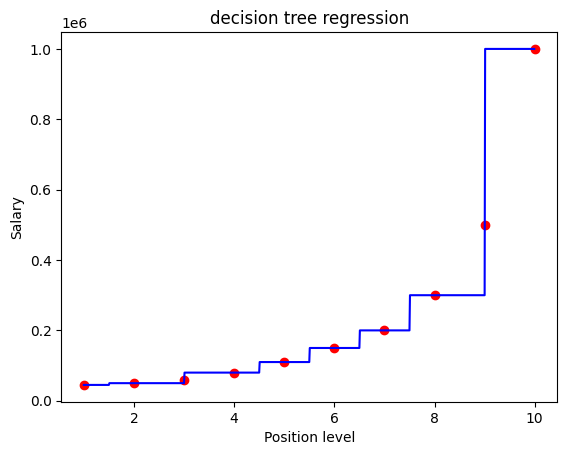

In [ ]:
# X의 최소값에서 최대값 까지 0.01간격으로 값을 생성함 - X_grid배열 생성
# 모델이 예측할 입력 값의 범위를 더 세밀하게 나타내기 위해서 입니다.  
X_grid =  np.arange(np.min(X), np.max(X), 0.01)
# 값을 강제로 2차 배열형태로 전환
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color="red")
# predict호출시 파라미터로 2차 배열을 원하기 때문입니다.  
plt.plot(X_grid, model.predict(X_grid), color="blue")
plt.title("decision tree regression")
plt.xlabel("Position level")
plt.ylabel("Salary")
# 예측값들을 나타내서 실제 데이터와 어떻게 다른지 시각적으로 보여 줍니다. 
plt.show()

STEP#8 - 평균제곱 오차 구하기

In [ ]:
from sklearn.metrics import mean_squared_error
pred = model.predict(X_test)
# 제곱오차가 200.5억이 나온 이유는 ( 실제값-예측값 )**2 와 같이 제곱을 했기 때문에 큰 숫자가 나옴
mse = mean_squared_error(y_test, pred)
print('MSE-평균제곱오차 : ', {mse})
# 약 14만 달러 정도 어긋남
print(f'200.5억을 루트씌운 값으로 단위를 복원하기 : {mse**0.5}')


MSE-평균제곱오차 :  {20050000000.0}
200.5억을 루트씌운 값으로 단위를 복원하기 : 141598.02258506295


정리<br>
데이터가 10개뿐이고 테스트 데이터는 2개라는 것임.<br>
의사결정 나무 회귀가 분할에 민감 또는 과적합 /과소적합으로 인해 오차가 커질 수도 있다<br>
MSE값이 200.5억이 나온 것은 데이터 규모, 모델 특성 때문에 그렇다<br>
다만 화폐단위와 제곱을 취한 이유로 정확한 숫자는 루트를 씌운값으로 봐야 한다<br>

K-Fole 교차 검증으로 MSE안정성 확인하기 - 모델 평가 핵심 기법<br>
```txt
왜 K-Fold가 필요한가?
데이터가 적을 때 매우 유영한 방법이다.

문제 제기
테이터가 적으면 20% 테스트에 뭐가 들어가느냐에 따라 성능이 크게 달라짐.
-> 평가가 운에 좌우됨...
K-Fold의 아이디어
데이터를 K개로 나누고 K번 반복하면서 평가를 한다.
무엇이 좋은가?
모든 데이터를 한 번씩 테스트에 사용함.
평가가 안정적임
특히 작은 데이터에서는 효과적인 방법임

언제 사용하나요?
데이터가 1000개 이하일 때

모델 비교 실험
하이퍼파라미터 튜닝
논문/ 보고서 읽거나 작성할 때 볼 수 있다.```

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

# 회귀에서 MSE는 scoring="neg_mean_squared_error" (sklearn은 점수 클수록 좋다고 가정 → MSE는 음수로 반환)
mse_scores = cross_val_score(
    DecisionTreeRegressor(random_state=0),
    X, y,
    cv=5,
    scoring="neg_mean_squared_error"
)

# 음수 MSE를 양수 MSE로 바꿔 해석
mse_scores = -mse_scores
print("폴드별 MSE:", mse_scores)
print("평균 MSE: %.2f" % mse_scores.mean())
print("표준편차 MSE: %.2f" % mse_scores.std())
print("평균 RMSE: %.2f" % (mse_scores.mean() ** 0.5))

폴드별 MSE: [1.625e+08 5.000e+08 1.700e+09 2.125e+10 2.650e+11]
평균 MSE: 57722500000.00
표준편차 MSE: 103942574410.10
평균 RMSE: 240255.07


---

```txt
정리
데이터가 10개뿐이고 5-fold라 폴드당 테스트 2개로 검증함.
즉 어떤 2개가 들어오는가에 따라 MSE가 극단적으로 달라짐(여기선 5번 폴드가 해당됨)
표준편차 > 평균이면 분포가 한쪽으로 쏠린 상태임

결론
의사결정 나무 회귀가 데이터 10개 폴드당 2개 검증이라는 조건에서 분할에 매우 불안정하는 것이
교차검증으로 증명 되었음

평균 RMSE가 약 24만 달러인것은 salary범위가 4.5만~100만 사이임을 고려하면 오차가 큰 편이며
데이터 수를 늘이거나 나무 깊이, 또는 과적합 제어를 고려 하는 것이 좋다고 판단됨.
```